In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sb
import time
import csv
import re

In [2]:
import json

with open("tracks.json", "r", encoding="utf-8") as f:
    tracks = json.load(f)

In [3]:
raw_data=pd.DataFrame(tracks)

In [4]:
df_cleaned = raw_data.copy()

# Overview

In [5]:
raw_data

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
0,TR934808,ART04205421,​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",186522.0
1,TR760029,ART04205421,POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",194313.0
2,TR916821,ART04205421,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']",...,2021-04-09,album,1.0,1.0,193544.0,True,39.0,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",63750.0
3,TR480968,ART04205421,CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...",...,2025-05-16,single,1.0,2.0,169000.0,True,47.0,ALB730959,Designer sui vestiti penso di essere un outlet...,41473.0
4,TR585039,ART04205421,LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,1,0,['cazzo'],...,2020-05-28,album,1.0,8.0,194779.0,True,41.0,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",30553.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11161,TR434449,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,None,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",4663.0
11162,TR826351,ART02733420,Senza Un Posto Nel Mondo - Alternative Version,Tiziano Ferro,Marracash,it,Senza Un Posto Nel Mondo – Single,1,0,['fortuna'],...,2015-02-10,album,1.0,20.0,248330.0,True,24.0,ALB100713,Odio questa città (città)\nSappiamo che la ver...,5686.0
11163,TR529809,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Exte...,None,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",5540.0
11164,TR280904,ART02733420,Tempo,None,Marracash,it,None,0,1,[],...,2015-02-10,album,1.0,7.0,302173.0,True,37.0,ALB100713,É crudo il suono e questa vibra che ti do\nCru...,4672.0


In [6]:
raw_data.disc_number.value_counts()

disc_number
1.0    10915
2.0      164
3.0        7
5.0        1
4.0        1
Name: count, dtype: int64

In [7]:
raw_data.album_type.value_counts()

album_type
album          9353
single         1544
compilation     191
Name: count, dtype: int64

In [8]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11166 entries, 0 to 11165
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11166 non-null  object 
 1   id_artist             11166 non-null  object 
 2   title                 11166 non-null  object 
 3   featured_artists      3517 non-null   object 
 4   primary_artist        11166 non-null  object 
 5   language              11061 non-null  object 
 6   album                 9652 non-null   object 
 7   swear_IT              11166 non-null  int64  
 8   swear_EN              11166 non-null  int64  
 9   swear_IT_words        11166 non-null  object 
 10  swear_EN_words        11166 non-null  object 
 11  year                  10722 non-null  float64
 12  month                 9969 non-null   float64
 13  day                   9843 non-null   float64
 14  n_sentences           11090 non-null  float64
 15  n_tokens           

In [9]:
spotifyAPI = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/DataPostSpotifyAPI.csv')
spotifyAPI

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
0,TR934808,ART04205421,​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",186522.0
1,TR760029,ART04205421,POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",194313.0
2,TR916821,ART04205421,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']",...,2021-04-09,album,1.0,1.0,193544.0,True,39.0,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",63750.0
3,TR480968,ART04205421,CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...",...,2025-05-16,single,1.0,2.0,169000.0,True,47.0,ALB730959,Designer sui vestiti penso di essere un outlet...,41473.0
4,TR585039,ART04205421,LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,1,0,['cazzo'],...,2020-05-28,album,1.0,8.0,194779.0,True,41.0,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",30553.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11158,TR434449,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,NaN,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",4663.0
11159,TR826351,ART02733420,Senza Un Posto Nel Mondo - Alternative Version,Tiziano Ferro,Marracash,it,Senza Un Posto Nel Mondo – Single,1,0,['fortuna'],...,2015-02-10,album,1.0,20.0,248330.0,True,24.0,ALB100713,Odio questa città (città)\nSappiamo che la ver...,5686.0
11160,TR529809,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Exte...,NaN,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",5540.0
11161,TR280904,ART02733420,Tempo,NaN,Marracash,it,NaN,0,1,[],...,2015-02-10,album,1.0,7.0,302173.0,True,37.0,ALB100713,É crudo il suono e questa vibra che ti do\nCru...,4672.0


#### Lyrics-based Profiling:
- n_sentences
- n_tokens
- char_per_tok
- avg_token_per_clause
- swear_IT, swear_EN
- swear_IT_words, swear_EN_words
- lyrics

#### Audio-based Profilling:
- bpm
- rolloff
- flux
- rms
- flatness
- spectral_complexity
- pitch
- loudness

#### Audio Feature Engineering
1. Tempo class
slow (<90 BPM)
medium (90–130 BPM)
fast (>130 BPM)

2. Energy score
Combine rms, loudness, and flux.

3. Brightness score
From rolloff + flatness.

4. Danceability proxy
Higher bpm + lower spectral flatness + high RMS.

1. “Energetic Dance Songs”
- High BPM
- High rolloff
- High loudness
- Bright timbre

2. “Dark Trap / Urban Rap”
- High profanity
- Heavy bass (high RMS)
- Low pitch
- Dark spectral features

3. “Slow Emotional Ballads”
- Low BPM
- Long lyrics
- High sentiment polarity (sad/negative)

4. “Romantic Pop”
- Medium BPM
- Positive sentiment
- Clean lyrics
- Simple structure

# Statistic

In [10]:
raw_data.select_dtypes(include=['int64','bool','float64']).describe().T

,count,mean,std,min,25%,50%,75%,max
swear_IT,11166.0,2.343006,3.704831,0.0000,0.000000,1.000000,3.000000,7.200000e+01
swear_EN,11166.0,0.711177,2.555423,0.0000,0.000000,0.000000,0.000000,7.200000e+01
year,10722.0,2015.135796,7.022598,1992.0000,2011.000000,2016.000000,2021.000000,2.025000e+03
month,9969.0,6.198515,3.482992,1.0000,3.000000,6.000000,10.000000,1.200000e+01
day,9843.0,15.808697,8.881989,1.0000,9.000000,16.000000,23.000000,3.100000e+01
n_sentences,11090.0,59.399639,24.711996,1.0000,46.000000,58.000000,73.000000,4.370000e+02
n_tokens,11090.0,496.891253,209.187612,3.0000,372.000000,491.000000,615.000000,3.089000e+03
char_per_tok,11090.0,4.054416,0.445958,2.0000,3.866946,4.012709,4.168686,1.200000e+01
avg_token_per_clause,11090.0,8.002009,14.577876,0.0000,5.859020,6.764171,8.090909,6.600000e+02
bpm,11102.0,114.134841,26.827124,59.9700,91.910000,106.975000,134.650000,7.382700e+02


In [11]:
raw_data.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
id,11166,11093,TR367132,4
id_artist,11166,104,ART91352277,353
title,11166,10521,Intro,36
featured_artists,3517,1740,Guè,64
primary_artist,11166,104,Mondo Marcio,353
language,11061,35,it,9352
album,9652,890,Rimo Da Quando,47
swear_IT_words,11166,2659,[],4176
swear_EN_words,11166,535,[],8426
album_name,11088,2421,SANTANA MONEY GANG,132


In [12]:
raw_data.describe(include="all").T 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,11166,11093,TR367132,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_artist,11166,104,ART91352277,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,11166,10521,Intro,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
featured_artists,3517,1740,Guè,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_artist,11166,104,Mondo Marcio,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,11061,35,it,9352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album,9652,890,Rimo Da Quando,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
swear_IT,11166.0,NaN,NaN,NaN,2.343006,3.704831,0.0,0.0,1.0,3.0,72.0
swear_EN,11166.0,NaN,NaN,NaN,0.711177,2.555423,0.0,0.0,0.0,0.0,72.0
swear_IT_words,11166,2659,[],4176,NaN,NaN,NaN,NaN,NaN,NaN,NaN


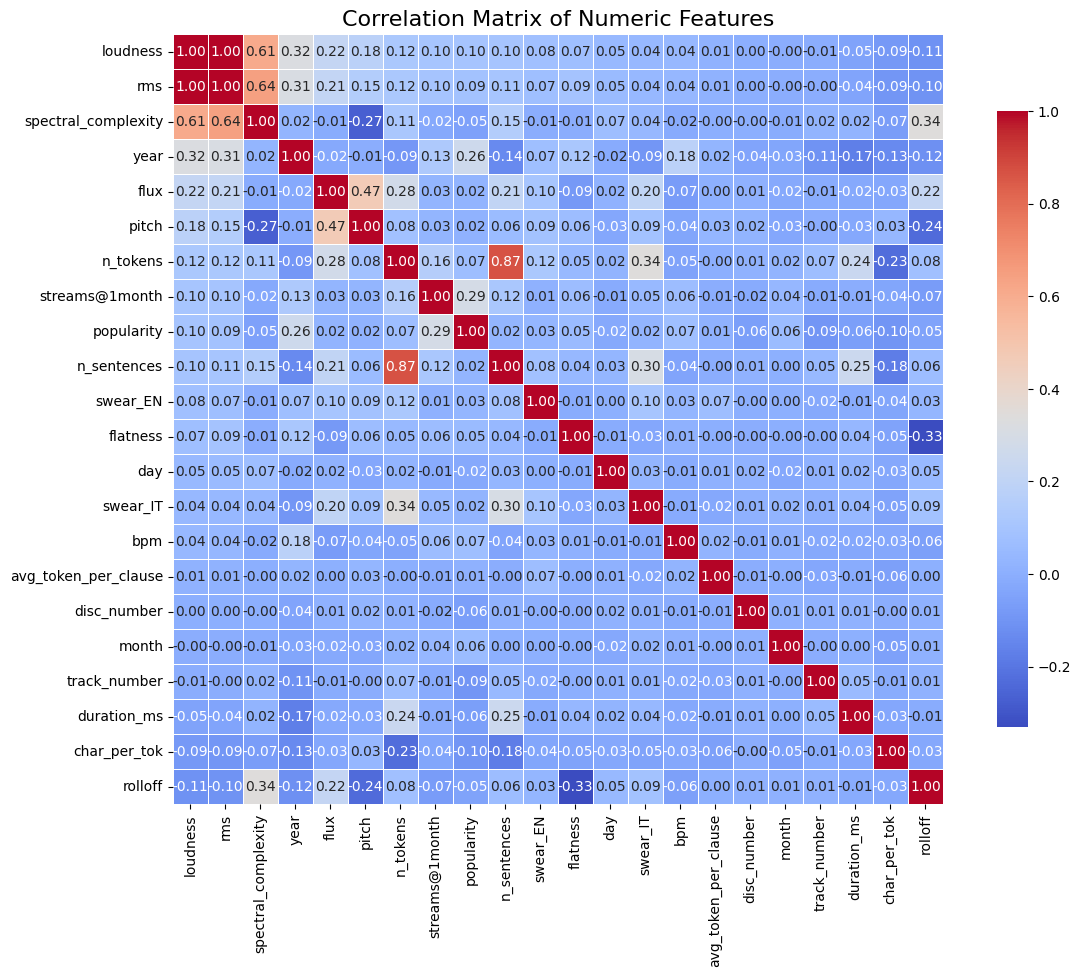

In [13]:
df = raw_data.copy()
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()
sorted_corr = corr['loudness'].sort_values(ascending=False)
sorted_correlation_df = corr.loc[sorted_corr.index, sorted_corr.index]
sorted_correlation_df.style.background_gradient(cmap='PuOr', vmin=-1, vmax=1)

plt.figure(figsize=(14, 10))
sns.heatmap(sorted_correlation_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5, square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()

# Handling missing value

In [14]:
def missing_values(data : pd.DataFrame, threshold : float = 10):

    na_count = data.isna().sum()
    na_exist = na_count[na_count > 0]
    na_abs_frq = na_exist.values
    na_rel_frq = round(na_exist/len(data)*100)
    missings = pd.DataFrame({'Nº of missings': na_abs_frq, '% of missings': na_rel_frq})
    missings = missings.sort_values(by = 'Nº of missings', ascending = False)

    if threshold:
        missings['Above threshold'] = [True if x > threshold else False for x in missings['% of missings']]
    
    return missings

missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
featured_artists,7649,69.0,True
album,1514,14.0,True
day,1323,12.0,True
month,1197,11.0,True
year,444,4.0,False
language,105,1.0,False
explicit,78,1.0,False
album_type,78,1.0,False
disc_number,78,1.0,False
track_number,78,1.0,False


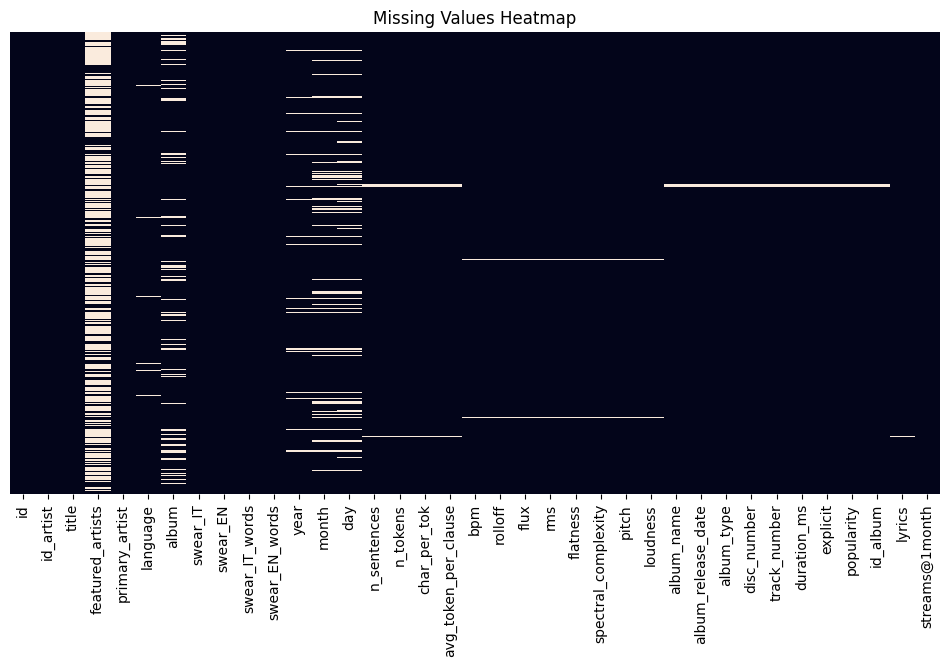

In [15]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

- use spotifyAPI to fill first then computed the other
- use lyrics to fill n_sentences + n_tokens + char_per_tok + avg_token_per_clause
- lyrics to fill language (?!)

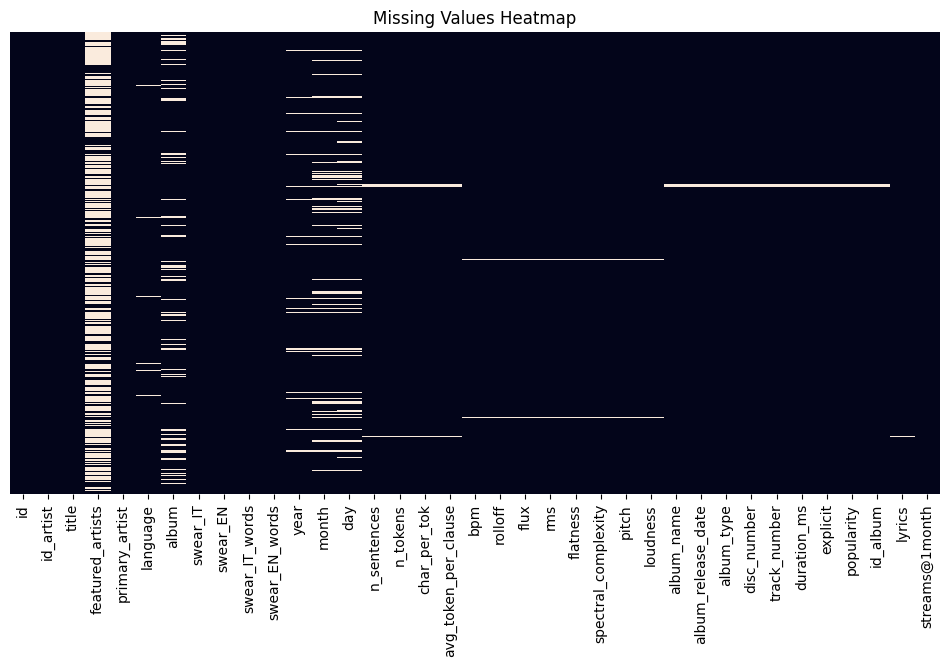

In [16]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

## using Spotify API

In [17]:
with open("tracks.json", "r", encoding="utf-8") as f:
    tracks = json.load(f)

with open(
    "/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/DataPostSpotifyAPI.csv",
    newline="",
    encoding="utf-8"
) as f:
    spotifyAPI = list(csv.DictReader(f))

fill_columns = [
    "lyrics", "featured_artists", "album", "language",
    "year", "month", "day", "bpm", "rolloff", "rms", "flux",
    "spectral_complexity", "pitch", "flatness", "loudness",
    "album_name", "album_type", "disc_number", "track_number",
    "album_release_date", "id_album", "duration_ms",
    "explicit", "popularity"
]

spotify_clean = {}

for row in spotifyAPI:
    key = (row["id"], row["id_artist"])

    filled_count = sum(
        1 for c in fill_columns
        if row.get(c) not in (None, "", [])
    )

    if key not in spotify_clean:
        spotify_clean[key] = (filled_count, row)
    else:
        if filled_count > spotify_clean[key][0]:
            spotify_clean[key] = (filled_count, row)

spotify_lookup = {
    key: value[1] for key, value in spotify_clean.items()
}
def is_missing(val):
    return val is None or val == "" or val == []
filled_rows = 0

for track in tracks:
    key = (track.get("id"), track.get("id_artist"))

    if key not in spotify_lookup:
        continue

    source = spotify_lookup[key]
    updated = False

    for col in fill_columns:
        if is_missing(track.get(col)) and not is_missing(source.get(col)):
            track[col] = source[col]
            updated = True

    if updated:
        filled_rows += 1

print(f"Filled missing values for {filled_rows} tracks using Spotify API.")

with open("tracks_filled.json", "w", encoding="utf-8") as f:
    json.dump(tracks, f, ensure_ascii=False, indent=2)

with open("tracks_filled.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=tracks[0].keys())
    writer.writeheader()
    writer.writerows(tracks)

Filled missing values for 73 tracks using Spotify API.


In [18]:
df_cleaned=pd.read_csv('tracks_filled.csv')
df_cleaned

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
0,TR934808,ART04205421,​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,13,6,"['cazzo', 'cesso', 'coglioni', 'figa', 'merda'...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",186522.0
1,TR760029,ART04205421,POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,9,12,"['cazzo', 'culo', 'frocio', 'puttana', 'sega',...",...,2021-04-09,album,1.0,3.0,207761.0,True,46.0,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",194313.0
2,TR916821,ART04205421,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,16,12,"['bastardo', 'cazzo', 'culo', 'merda', 'troia']",...,2021-04-09,album,1.0,1.0,193544.0,True,39.0,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",63750.0
3,TR480968,ART04205421,CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,8,3,"['cazzo', 'culo', 'fottere', 'merda', 'pompino...",...,2025-05-16,single,1.0,2.0,169000.0,True,47.0,ALB730959,Designer sui vestiti penso di essere un outlet...,41473.0
4,TR585039,ART04205421,LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,1,0,['cazzo'],...,2020-05-28,album,1.0,8.0,194779.0,True,41.0,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",30553.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11161,TR434449,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,NaN,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",4663.0
11162,TR826351,ART02733420,Senza Un Posto Nel Mondo - Alternative Version,Tiziano Ferro,Marracash,it,Senza Un Posto Nel Mondo – Single,1,0,['fortuna'],...,2015-02-10,album,1.0,20.0,248330.0,True,24.0,ALB100713,Odio questa città (città)\nSappiamo che la ver...,5686.0
11163,TR529809,ART02733420,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Exte...,NaN,Marracash,it,Badabum Cha Cha (The Remixes),0,0,[],...,2016-07-01,single,1.0,1.0,234374.0,False,57.0,ALB248347,"Qui non va, ma questo badabum cha cha\nTira fo...",5540.0
11164,TR280904,ART02733420,Tempo,NaN,Marracash,it,NaN,0,1,[],...,2015-02-10,album,1.0,7.0,302173.0,True,37.0,ALB100713,É crudo il suono e questa vibra che ti do\nCru...,4672.0


In [19]:
spotifyAPI = pd.read_csv('/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/DataPostSpotifyAPI.csv')
raw_data["id"].duplicated().sum(), spotifyAPI["id"].duplicated().sum()

(np.int64(73), np.int64(73))

In [20]:
dupes = raw_data[raw_data["id"].duplicated(keep=False)]
dupes.sort_values("id")

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
4240,TR108862,ART56320683,Sushi Bar,None,Bassi Maestro,en,Sushi EP,8,1,"['bastardo', 'cesso', 'culo', 'fesso', 'merda']",...,2007-11-13,single,1.0,3.0,215461.0,True,6.0,ALB697589,Questo mondo resta freddo anche se vivi da sta...,5367.0
7786,TR108862,ART07127070,SPINE,Coez,Noyz Narcos,cs,VIRUS (Deluxe),1,0,['scopare'],...,2022-01-14,album,1.0,6.0,155294.0,True,44.0,ALB525038,Sei al centro del mio cuore come 'na spina\nSe...,17849.0
3199,TR135764,ART73965015,Nessuno vale quanto te,None,Ghemon,it,ORCHIdee,0,0,[],...,2014-05-27,album,1.0,8.0,238773.0,False,26.0,ALB346809,Dicono che da un posto piccolo non può venire ...,6875.0
5847,TR135764,ART86549066,Giovani eroi,Not Good,Emis Killa,it,"Keta Music, Vol. 3",5,1,"['bastardo', 'cazzo', 'merda', 'troia']",...,2021-07-23,album,1.0,10.0,152733.0,True,35.0,ALB168242,"Oh, la city è silenziosa, in zona solo un clac...",14390.0
8104,TR190585,ART78209349,Nei treni la notte,Frah Quintale,Coez,it,From The Rooftop 2,0,0,[],...,2022-10-14,album,1.0,3.0,181789.0,False,43.0,ALB760031,Ho fatto un giro in questa città\nEd è come fa...,5618.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2474,TR980497,ART48537029,Te-le-co-man-do,None,Mistaman,it,Anni senza fine,7,0,"['cagare', 'cazzo', 'coglioni', 'cretini', 'fi...",...,2008-07-29,album,1.0,8.0,215373.0,True,7.0,ALB102546,"Click, okay l'ho fatto, ti ho riaccesa\nBella ...",5081.0
4190,TR987615,ART56320683,Django Muzik,Mondo Marcio,Bassi Maestro,it,Guarda In Cielo,6,0,"['cazzo', 'culo', 'merda']",...,2014-05-28,single,1.0,1.0,245394.0,True,16.0,ALB916617,Se avessi un'altra chance\nSarei molto più cin...,5524.0
1318,TR987615,ART63613967,Polo Nord,None,Massimo Pericolo,en,None,7,0,"['cazzo', 'culo', 'merda', 'puttana']",...,2019-09-27,album,1.0,12.0,249303.0,False,53.0,ALB409177,"And in my mind, in my head\nThis is where we a...",64575.0
10375,TR997536,ART91352277,Vida Loca,None,Mondo Marcio,co,UOMO!,1,1,['fica'],...,2019-03-08,album,1.0,5.0,181800.0,True,24.0,ALB145056,Se parto tu mi segui a ruota (Yeh-yeah)\nTropp...,5060.0


same id (track) but difference info => error data

## drop rms

- correlation matix showed that 'rms' and 'loudness' are high correlation (=1)
- after filling with sprotifyAPI, these 2 columns still the same

=> drop 'rms', keep 'loudness'

In [21]:
input_path = "tracks_filled.csv"
output_path = "tracks_filled.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

fieldnames = [col for col in fieldnames if col != "rms"]

for row in rows:
    row.pop("rms", None)

with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Column 'rms' removed. Saved to tracks_filled.csv")

Column 'rms' removed. Saved to tracks_filled.csv


## lyrics

In [22]:
df_nalyrics=df_cleaned[df_cleaned.lyrics.isnull()]

In [23]:
missing_values(df_nalyrics)

,Nº of missings,% of missings,Above threshold
featured_artists,3,100.0,True
n_sentences,3,100.0,True
n_tokens,3,100.0,True
char_per_tok,3,100.0,True
avg_token_per_clause,3,100.0,True
lyrics,3,100.0,True
album,2,67.0,True


In [24]:
df_nalyrics

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
6950,TR105319,ART46711784,Consegnato.02,NaN,Frah Quintale,it,NaN,0,0,[],...,2021-12-12,single,1.0,1.0,155946.0,True,0.0,ALB903727,NaN,5519.0
6952,TR252811,ART46711784,Consegnato.01,NaN,Frah Quintale,it,NaN,0,0,[],...,2018-06-29,album,1.0,21.0,92125.0,False,25.0,ALB635494,NaN,4906.0
9775,TR590611,ART48622722,Introliberassociazione,NaN,Salmo,it,Sotto Pelle,0,0,[],...,2018-11-09,album,1.0,13.0,205266.0,True,60.0,ALB370362,NaN,4944.0


In [25]:
df_cleaned[df_cleaned.id_album=='ALB635494']

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
6888,TR492037,ART46711784,Missili,Giorgio Poi,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,12.0,195349.0,False,69.0,ALB635494,Ti si riempiono gli occhi con le onde del mare...,66351.0
6894,TR155178,ART46711784,64 Bars,NaN,Frah Quintale,it,Lungolinea.,6,1,"['cazzo', 'culo', 'fottuto', 'sfiga']",...,2018-06-29,album,1.0,15.0,188738.0,False,50.0,ALB635494,Busdeez\n\nÈ il ritorno del guaglione con la f...,40792.0
6896,TR383581,ART46711784,Gravità,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,11.0,215383.0,False,57.0,ALB635494,Il brano parla dell'importanza per Frah di ave...,42455.0
6900,TR232253,ART46711784,Stupefacente,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,20.0,187245.0,False,50.0,ALB635494,"C'è la droga dentro a quegli abbracci, uh, uh\...",21831.0
6902,TR448207,ART46711784,Colpa del vino,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,3.0,173333.0,False,53.0,ALB635494,"Mi sveglio pensando: ""È mattina"", ma sono le t...",19292.0
6905,TR904234,ART46711784,Fare su,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,16.0,157366.0,False,40.0,ALB635494,"Vento sulla faccia, direzione altrove\nNel mio...",14194.0
6912,TR606153,ART46711784,Sassi,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,5.0,176843.0,False,42.0,ALB635494,Così in silenzio in macchina che la pioggia su...,11149.0
6917,TR671803,ART46711784,Sotto effetto,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,1.0,191703.0,False,39.0,ALB635494,Ora che ho tutto quello per cui perdevo sangue...,10553.0
6925,TR881470,ART46711784,Sabato nel parco,NaN,Frah Quintale,it,Lungolinea.,0,0,[],...,2018-06-29,album,1.0,18.0,176727.0,False,36.0,ALB635494,"Se mi chiami, scendo subito (La-la-la, la-la-l...",5373.0
6936,TR385765,ART46711784,Visualizzato.01,NaN,Frah Quintale,it,Lungolinea.,6,0,"['cazzo', 'figa', 'figo', 'merda']",...,2018-06-29,album,1.0,4.0,137142.0,False,28.0,ALB635494,"Eh, ho visto che...\nOh Frah, vieni al Carmen ...",4648.0


- Remove rows with missing in lyrics

In [26]:
input_path = "tracks_filled.csv"
output_path = "tracks_filled.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

filtered_rows = []

for row in rows:
    lyrics = row.get("lyrics")

    if lyrics is None:
        continue

    if lyrics.strip() == "":
        continue

    filtered_rows.append(row)

with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(filtered_rows)

print(f"Removed rows with empty lyrics. Remaining rows: {len(filtered_rows)}")

Removed rows with empty lyrics. Remaining rows: 11163


## featured_artists

In [27]:
df_cleaned.album_type.value_counts()

album_type
album          9419
single         1549
compilation     191
Name: count, dtype: int64

In [28]:
df_cleaned[df_cleaned.album_type == 'compilation']

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
73,TR957619,ART19605256,WIMBLEDON (64 Bars),NaN,Beba,pl,"RED BULL 64 BARS, The Album",3,0,"['figa', 'fortuna', 'palle']",...,2021-05-27,compilation,1.0,7.0,185777.0,True,37.0,ALB670345,"Ehi\nDat Boi Dee, vamos pa' la banca, ahah\nVa...",20603.0
279,TR735016,ART88026810,Night Cherry,NaN,thasup,it,NaN,0,0,[],...,2025-06-11,compilation,1.0,17.0,203161.0,True,2.0,ALB266926,8 ContributorsNight Cherry Lyrics,5607.0
366,TR213067,ART39344115,MEZZO SPORT (64 Bars),NaN,Lazza,it,"RED BULL 64 BARS, The Album",4,1,"['cazzo', 'culo', 'fortuna', 'sfiga']",...,2021-05-27,compilation,1.0,13.0,132428.0,True,49.0,ALB888447,"Ehi, a 'sti bambocci della musica non gli freg...",70008.0
456,TR486985,ART39344115,A Me,SHINE,Lazza,en,K1 Mixtape,3,2,"['cesso', 'culo', 'merda']",...,2021-05-27,compilation,1.0,13.0,132428.0,True,49.0,ALB888447,Telaviv leave that shit for me honey\nBlocco R...,4035.0
468,TR199593,ART39344115,LAST BARS,NaN,Lazza,it,NaN,2,1,"['cazzo', 'merda']",...,2025-06-18,compilation,1.0,30.0,290892.0,True,0.0,ALB376343,"È finito il video, dai la macchina indietro\nS...",4459.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10799,TR729696,ART52465778,F.D.P. 2,NaN,Fred De Palma,it,Genesi,11,0,"['cazzo', 'figa', 'puttana']",...,2024-08-03,compilation,1.0,3.0,163308.0,True,38.0,ALB630403,In mano ho solo sette note\nCompro pantaloni c...,4207.0
11026,TR270415,ART02733420,64 BARRE DI PAURA,NaN,Marracash,it,"RED BULL 64 BARS, The Album",3,1,"['cazzo', 'fica']",...,2021-05-27,compilation,1.0,11.0,131777.0,True,56.0,ALB920529,"Yeah, Marracash\nSessantaquattro bars di paura...",71784.0
11032,TR228628,ART02733420,64 BARRE DI VITTORIA,NaN,Marracash,it,"RED BULL 64 BARS, The Album",3,0,"['coglioni', 'fottuto']",...,2021-05-27,compilation,1.0,14.0,146353.0,True,44.0,ALB920529,"Yeah\nAlzami un po' la voce in cuffia\nAh, yea...",75156.0
11134,TR577582,ART02733420,Casbah Flow,Guè,Marracash,pl,Double Dragon Mixtape,1,0,['culo'],...,2008-08-18,compilation,1.0,4.0,183306.0,False,14.0,ALB396952,"(Ah, la zona è Barona)\nSe se (Marracash), Luc...",5891.0


In [29]:
df_cleaned[df_cleaned.album_type == 'compilation'].featured_artists.isna().sum()

np.int64(126)

In [30]:
df_cleaned[df_cleaned.album_type == 'single'].featured_artists.isna().sum()

np.int64(1153)

In [31]:
df_cleaned[df_cleaned.album_type == 'album'].featured_artists.isna().sum()

np.int64(6362)

- Infer from title or album_name or album (if they have text like 'feat.')

In [32]:
def normalize_name(s):
    if not isinstance(s, str):
        return s
    s = s.strip()
    s = s.strip("()[]{} \u2018\u2019\u201c\u201d")
    s = re.sub(r'^[^0-9A-Za-zÀ-ÖØ-öø-ÿ]+', '', s)
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[\.\,\;\:\-\/\|]+$', '', s).strip()
    return s.title()
def split_artists(raw):
    if not raw or not isinstance(raw, str):
        return None

    parts = re.split(
        r'\s*(?:,|&|;|\/| and | feat | ft | featuring )\s*',
        raw,
        flags=re.IGNORECASE
    )

    names = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        p = re.sub(r'^\(+|\)+$', '', p).strip()
        p = re.sub(r'^[^0-9A-Za-zÀ-ÖØ-öø-ÿ]+', '', p)
        p = re.sub(r'\b(?:feat|ft|featuring)\b[\.]?$','', p, flags=re.IGNORECASE).strip()
        if p:
            names.append(normalize_name(p))

    if not names:
        return None

    seen = set()
    out = []
    for n in names:
        if n not in seen:
            seen.add(n)
            out.append(n)

    return ", ".join(out) if out else None

def extract_feat(text):
    if not isinstance(text, str):
        return None

    txt = text.strip()

    pattern = re.compile(
        r"\b(?:feat(?:\.|uring)?|ft(?:\.)?)\b[:\s\-–—]*([^)\;\,\-:]{1,300})",
        flags=re.IGNORECASE
    )

    matches = pattern.findall(txt)

    if not matches:
        paren_match = re.search(r"\(([^)]+)\)", txt)
        if paren_match:
            candidate = paren_match.group(1)
            if re.search(r"(?:,|&|ft|feat|featuring|and|/)", candidate, flags=re.IGNORECASE):
                return split_artists(candidate)
        return None

    combined = " / ".join(m.strip() for m in matches if m.strip())
    return split_artists(combined)

def fill_featured_artists(rows):
    text_fields = ["title", "album_name", "album"]
    filled_log = []

    for idx, row in enumerate(rows):
        current = row.get("featured_artists")

        if current and str(current).strip() != "":
            continue

        extracted = None
        used_col = None
        used_text = None

        for col in text_fields:
            src_text = row.get(col)
            if not isinstance(src_text, str):
                continue

            feat = extract_feat(src_text)
            if feat:
                extracted = feat
                used_col = col
                used_text = src_text
                break

        if extracted:
            row["featured_artists"] = extracted
            snippet = (
                used_text[:140] + "..."
                if used_text and len(used_text) > 140
                else (used_text or "")
            )
            filled_log.append((idx, snippet, extracted, used_col))

    # Logging
    print("\nFEATURED ARTISTS INFERRED FROM TEXT:\n")
    for idx, src, artist, col in filled_log:
        print(f"Row {idx} | '{src}' → '{artist}' (from {col})")
    print(f"\nTotal inferred rows: {len(filled_log)}")

    return rows

input_path = "tracks_filled.csv"
output_path = "tracks_filled.csv"

# Read CSV
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

# Process
rows = fill_featured_artists(rows)

# Write CSV
with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"\nSaved result to {output_path}")


FEATURED ARTISTS INFERRED FROM TEXT:

Row 45 | 'COMINCIA TU (feat. Rosa Chemical)' → 'Rosa Chemical' (from album_name)
Row 69 | 'COMINCIA TU (feat. Rosa Chemical)' → 'Rosa Chemical' (from album_name)
Row 129 | 'a me mi piace (feat. Manu Chao)' → 'Manu Chao' (from album_name)
Row 183 | 'a me mi piace (feat. Manu Chao)' → 'Manu Chao' (from album_name)
Row 194 | 'Les plus belles polyphonies Corses (Les plus grandes polyphonies de Corses)' → 'Les Plus Grandes Polyphonies De Corses' (from album_name)
Row 299 | 'Che Gusto C'è (feat. Tredici Pietro)' → 'Tredici Pietro' (from album_name)
Row 443 | 'Verdi: Rigoletto (Callas, Di Stefano, Gobbi / La Scala) (1955)' → 'Callas, Di Stefano, Gobbi, La Scala' (from album_name)
Row 753 | 'La gatta (feat. Vacca, Primo, Ntò, Amir, Bassi Maestro & Mondo Marcio) [Remix]' → 'Vacca' (from album_name)
Row 776 | 'SPOILER 2 (feat. 22simba)' → '22Simba' (from album_name)
Row 1011 | 'Middle Finger (XL & Rock IT Dissing)' → 'Xl, Rock It Dissing' (from title)
Row 1

- Fill 'Various artists' for 'album_name' == 'compilation'
- Fill 'NO_FEATURE' for the rest

In [33]:
input_path = "tracks_filled.csv"
output_path = "tracks_filled.csv"

# Read CSV
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

# Fill featured_artists
for row in rows:
    album_type = row.get("album_type")
    featured = row.get("featured_artists")

    is_missing = featured is None or str(featured).strip() == ""

    if album_type == "compilation" and is_missing:
        row["featured_artists"] = "Various Artists"
    elif is_missing:
        row["featured_artists"] = "no feature"

with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Filled missing featured_artists and saved output.")

Filled missing featured_artists and saved output.


In [34]:
df_cleaned = pd.read_csv ('tracks_filled.csv')
df_cleaned.featured_artists.isna().sum()

np.int64(0)

In [35]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11163 entries, 0 to 11162
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11163 non-null  object 
 1   id_artist             11163 non-null  object 
 2   title                 11163 non-null  object 
 3   featured_artists      11163 non-null  object 
 4   primary_artist        11163 non-null  object 
 5   language              11058 non-null  object 
 6   album                 9653 non-null   object 
 7   swear_IT              11163 non-null  int64  
 8   swear_EN              11163 non-null  int64  
 9   swear_IT_words        11163 non-null  object 
 10  swear_EN_words        11163 non-null  object 
 11  year                  10719 non-null  float64
 12  month                 9966 non-null   float64
 13  day                   9840 non-null   float64
 14  n_sentences           11090 non-null  float64
 15  n_tokens           

## n_tokens, n_sentences ,... 

- Compute from 'lyrics'

In [36]:
def compute_text_features(rows):
    """
    Compute text features based on 'lyrics' field:
        - n_tokens
        - n_sentences
        - char_per_tok
        - avg_token_per_clause
    Modifies rows in place and returns them.
    """

    for row in rows:
        text = row.get("lyrics")

        # Default values (equivalent to filling NA with 0)
        row["n_tokens"] = 0
        row["n_sentences"] = 0
        row["char_per_tok"] = 0.0
        row["avg_token_per_clause"] = 0.0

        if not isinstance(text, str) or text.strip() == "":
            continue

        # -------------------------------
        # 1) TOKENS
        # -------------------------------
        tokens = re.findall(r"\b\w+\b", text, flags=re.UNICODE)
        n_tokens = len(tokens)

        # -------------------------------
        # 2) SENTENCES
        # -------------------------------
        sentences = re.split(r"[.!?]+", text)
        sentences = [s.strip() for s in sentences if s.strip()]
        n_sentences = len(sentences)

        # -------------------------------
        # 3) avg characters per token
        # -------------------------------
        char_per_tok = (
            sum(len(t) for t in tokens) / n_tokens
            if n_tokens > 0 else 0.0
        )

        # -------------------------------
        # 4) avg tokens per clause
        # -------------------------------
        clauses = re.split(r"[,;:\-\n]+", text)
        clauses = [c.strip() for c in clauses if c.strip()]
        n_clauses = len(clauses)

        avg_token_per_clause = (
            n_tokens / n_clauses
            if n_clauses > 0 else 0.0
        )

        # Assign (round like pandas version)
        row["n_tokens"] = n_tokens
        row["n_sentences"] = n_sentences
        row["char_per_tok"] = round(char_per_tok, 4)
        row["avg_token_per_clause"] = round(avg_token_per_clause, 4)

    return rows

input_path = "tracks_filled.csv"
output_path = "tracks_filled.csv"

# Read CSV
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

# Compute features
rows = compute_text_features(rows)

# Add new columns if not present
new_cols = ["n_tokens", "n_sentences", "char_per_tok", "avg_token_per_clause"]
for c in new_cols:
    if c not in fieldnames:
        fieldnames.append(c)

# Write CSV
with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Computed text features and saved CSV.")

Computed text features and saved CSV.


In [37]:
df_cleaned = pd.read_csv ('tracks_filled.csv')
df_cleaned.n_tokens.isna().sum(), df_cleaned.n_sentences.isna().sum(),df_cleaned.char_per_tok.isna().sum(), df_cleaned.avg_token_per_clause.isna().sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

## language

- Detect language directly from "lyrics"
- If multiple languages appear → choose the language with the highest percentage

In [38]:
from langdetect import detect_langs

def detect_main_language(text):
    """
    Detect main language from lyrics.
    """
    if not isinstance(text, str) or text.strip() == "":
        return "unknown"

    # Clean text
    cleaned = re.sub(r"[^A-Za-zÀ-ÖØ-öø-ÿ ]+", " ", text)

    # Try langdetect
    try:
        langs = detect_langs(cleaned)
        if langs:
            langs_sorted = sorted(langs, key=lambda x: x.prob, reverse=True)
            return langs_sorted[0].lang
    except Exception:
        pass

    # Fallback heuristic
    text_low = cleaned.lower()
    italian_chars = sum(text_low.count(c) for c in "àèéìòóù")
    english_chars = sum(text_low.count(c) for c in "wkjqxz")

    if italian_chars > english_chars:
        return "it"
    elif english_chars > italian_chars:
        return "en"
    else:
        return "unknown"

input_path = "tracks_filled.csv"

# 1. Read CSV
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

# 2. Fill language column
for row in rows:
    lyrics = row.get("lyrics")
    row["language"] = detect_main_language(lyrics)

# 3. Write CSV (overwrite)
with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Language column filled and file overwritten.")

Language column filled and file overwritten.


In [39]:
df_cleaned = pd.read_csv ('tracks_filled.csv')
df_cleaned.language.isna().sum()

np.int64(0)

In [40]:
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
album,1510,14.0,True
day,1323,12.0,True
month,1197,11.0,True
year,444,4.0,False
flatness,64,1.0,False
pitch,64,1.0,False
spectral_complexity,64,1.0,False
loudness,64,1.0,False
flux,64,1.0,False
rolloff,64,1.0,False


## audio signal features (bpm, rolloff,...)

In [41]:
df_cleaned[['bpm','rolloff','flux','pitch','flatness','loudness','spectral_complexity']]

,bpm,rolloff,flux,pitch,flatness,loudness,spectral_complexity
0,135.32,2895.7767,1.4499,2311.1779,0.8202,17.8675,25.7148
1,129.37,3378.4605,1.3533,1892.1924,0.6739,21.4595,29.1089
2,133.68,2037.4847,1.3822,2484.3503,0.7842,29.4590,26.9762
3,162.22,1156.3781,1.5499,2984.6109,0.8764,20.5067,14.2956
4,105.87,1693.4542,1.0886,1572.0499,0.8571,25.3407,36.6951
...,...,...,...,...,...,...,...
11158,123.78,1140.5174,1.4162,3067.5304,0.9118,26.3440,20.9760
11159,172.27,1588.1965,1.1842,2537.0837,0.9159,33.5024,41.3077
11160,123.82,1130.7621,1.4001,3071.3804,0.8892,25.4605,21.4218
11161,86.99,1495.6718,1.2661,2754.6887,0.9404,32.5964,26.1900


- bpm: Beats per minute of the track (tempo).
- rolloff: Spectral rolloff frequency — measure of brightness/sharpness.
- flux: Spectral flux — how much the spectrum changes frame-to-frame (timbral variation).
- rms: RMS energy — perceived loudness and intensity.
- flatness: Spectral flatness — how noise-like the audio is (0 = tone, 1 = noise).
- spectral_complexity: Harmonic/spectral complexity of the audio.
- pitch: Estimated predominant pitch of the track.
- loudness: Average loudness in dB (lower = quieter).

=> Cannot infer from other features

=> Fill NA = '-1'

In [42]:
audio_cols = [
    "bpm",
    "rolloff",
    "flux",
    "pitch",
    "flatness",
    "loudness",
    "spectral_complexity"
]

input_path = "tracks_filled.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

for row in rows:
    for col in audio_cols:
        val = row.get(col)

        is_missing = (
            val is None or
            str(val).strip() == ""
        )

        if is_missing:
            row[col] = "-1"   

with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Filled missing audio features with -1 and overwrote file.")

Filled missing audio features with -1 and overwrote file.


In [43]:
df_cleaned = pd.read_csv ('tracks_filled.csv')
df_cleaned[audio_cols].isna().sum()

bpm                    0
rolloff                0
flux                   0
pitch                  0
flatness               0
loudness               0
spectral_complexity    0
dtype: int64

## album, album_name

In [44]:
mask_non_empty = raw_data["album"].notna() & (raw_data["album"].astype(str).str.strip() != "")

df_album = raw_data[mask_non_empty].copy()

df_album["album_match"] = df_album["album"].str.lower().str.strip() == \
                          df_album["album_name"].str.lower().str.strip()

mismatched_rows = df_album[df_album["album_match"] == False]

print("Total non-empty album rows:", len(df_album))
print("Matching rows:", df_album["album_match"].sum())
print("Not matching rows:", len(mismatched_rows))

print("\nRows where album != album_name:")
mismatched_rows[["title","album", "album_name"]]

Total non-empty album rows: 9652
Matching rows: 4861
Not matching rows: 4791

Rows where album != album_name:


,title,album,album_name
3,CEO,OKAY OKAY !! - EP,OKAY OKAY 2
4,LONDRA,FOREVER AND EVER,FOREVER
5,BOHEME,FOREVER AND EVER,FOREVER
6,LOBBY WAY,FOREVER AND EVER,FOREVER
7,SLATT,FOREVER AND EVER,FOREVER
...,...,...,...
11158,Crack (Provino),Status (Vendetta Edition),"Status (Inediti, Rarità & Live)"
11160,Di Nascosto (Don Joe Demo 2014),Status (Vendetta Edition),"Status (Inediti, Rarità & Live)"
11161,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,Badabum Cha Cha (The Remixes),Che Ne Sanno I 2000 (feat. Danti)
11162,Senza Un Posto Nel Mondo - Alternative Version,Senza Un Posto Nel Mondo – Single,Status


In [45]:
df_cleaned[df_cleaned.album_name.isna()][["title","album", "album_name","album_type"]]

,title,album,album_name,album_type
3286,PTS (PoiTiSpiego/PostTraumaticStress),Embrionale - EP,NaN,NaN
3699,Passaporto Per Resistere,The World According to RZA,NaN,NaN
3711,Il Sonno Della Ragione,Zora la vampira,NaN,NaN
3738,School Rocks!,NaN,NaN,NaN
3739,Nuvole e vento (Africa),Capo Verde terra d’amore Vol. 9 (Canzoni di Ce...,NaN,NaN
6390,Ganja music,Carpe diem,NaN,NaN
9259,(Sei Tu) Che Mi Dai,NaN,NaN,NaN


In [46]:
df_cleaned[df_cleaned.album_name.isna() & df_cleaned.album.isna()][["title","album", "album_name","album_type"]]

,title,album,album_name,album_type
3738,School Rocks!,NaN,NaN,NaN
9259,(Sei Tu) Che Mi Dai,NaN,NaN,NaN


In [47]:
df_cleaned.album_type.isna().sum()

np.int64(7)

In [48]:
df_cleaned.title.duplicated().sum()

np.int64(645)

In [49]:
df_cleaned[df_cleaned.title.duplicated()]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
181,TR191602,ART18853907,COVID19 FREESTYLE,no feature,Alfa,it,NaN,0,0,[],...,2023-09-24,single,1.0,1.0,216322.0,True,5.0,ALB291183,Restiamo a casa così intanto scrivo il disco\n...,4237.0
333,TR255598,ART39344115,SLIME,Rondodasosa,Lazza,it,J,1,2,['troia'],...,2020-07-16,album,1.0,6.0,208233.0,True,57.0,ALB554542,"Ora cammino per la strada, qui mi sembra il So...",109310.0
460,TR674810,ART39344115,Montana,no feature,Lazza,it,K1 Mixtape,9,1,"['cazzi', 'coglioni', 'figa', 'fottere', 'sfig...",...,2022-04-07,album,1.0,11.0,173142.0,True,47.0,ALB261724,Is crazy\nTelaviv leave that shit for me honey...,4247.0
469,TR969235,ART39344115,Intro,no feature,Lazza,it,Destiny Mixtape,6,0,"['cagare', 'cazzo', 'culo', 'merda', 'stronzo'...",...,2023-06-29,single,1.0,1.0,150588.0,False,3.0,ALB933854,"Ah (Lazzino), Mr. Lazzino (Lazzino) in studio ...",5943.0
666,TR634614,ART62385172,Intro,no feature,Nerone,it,N Mixtape,0,0,[],...,2021-05-12,album,1.0,1.0,180000.0,False,29.0,ALB917245,"Eh, ricordo con le lacrime il giorno in cui li...",4506.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11090,TR839533,ART02733420,In Faccia,no feature,Marracash,it,King Del Rap,2,0,"['cazzo', 'merda']",...,2011-01-01,album,1.0,4.0,216053.0,True,39.0,ALB288289,Non è per la democrazia che bombardiamo la Lib...,19262.0
11091,TR996715,ART02733420,Crack,no feature,Marracash,it,Status (Vendetta Edition),2,0,"['culo', 'paraculo']",...,2015-02-10,album,1.0,13.0,292120.0,True,30.0,ALB100713,Lo diceva Beck: la sua prima track\nMTV fa ven...,20381.0
11134,TR736252,ART02733420,Stupidi,Fabri Fibra,Marracash,it,Fino A Qui Tutto Bene,15,0,"['cazzo', 'stronzo', 'stupida', 'stupido']",...,2021-11-19,album,1.0,11.0,201000.0,True,64.0,ALB342728,Fino a qui tutto bene\nFino a qui tutto bene\n...,6055.0
11142,TR106809,ART02733420,Regole,Misa,Marracash,it,Roccia Music,2,0,"['cazzi', 'pene']",...,2024-12-13,album,1.0,12.0,223009.0,True,75.0,ALB805518,"Queste sono le regole (Di strada, di strada)\n...",5359.0


In [50]:
df_cleaned[df_cleaned.album.isna()][["title","album", "album_name"]]

,title,album,album_name
10,POLKA 3,NaN,POLKA 3
21,Facciamolo,NaN,Facciamolo
22,Freestyle #redbullnext #essemagazine,NaN,OKAY OKAY 2
23,Scolapasta,NaN,BV3
24,#IORESTOACASA Freestyle,NaN,BV3
...,...,...,...
11153,Chi sale sul ring (Sigla MTV Spit),NaN,"Machete Mixtape, Vol. 3"
11154,Album Trailer 2,NaN,Monument
11156,Intro*,NaN,Persona
11161,Tempo,NaN,Status


- title == 'Freestyle #redbullnext #essemagazine' ?! => explore in next section

we can use 1 for database: 
- album: Official Spotify album name (track.album.name)
- album_name: Dataset-defined field (may include editions, remixes, local variations)

In [51]:
input_path = "tracks_filled.csv"
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
filled = 0

for row in rows:
    album = row.get("album")
    album_name = row.get("album_name")

    is_album_missing = (
        album is None or
        str(album).strip() == ""
    )

    if is_album_missing:
        if isinstance(album_name, str) and album_name.strip() != "":
            row["album"] = album_name.strip()
            filled += 1
with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"\nTotal filled album: {filled} rows")


Total filled album: 1508 rows


In [52]:
df_cleaned = pd.read_csv ('tracks_filled.csv')
df_cleaned.album.isna().sum()

np.int64(2)

In [53]:
df_cleaned[df_cleaned.album.isna()][["title","album", "album_name","album_type"]]

,title,album,album_name,album_type
3738,School Rocks!,NaN,NaN,NaN
9259,(Sei Tu) Che Mi Dai,NaN,NaN,NaN


In [54]:
df_cleaned[df_cleaned.album_type == 'single'][["title","album", "album_name","album_type"]]

,title,album,album_name,album_type
3,CEO,OKAY OKAY !! - EP,OKAY OKAY 2,single
8,MADE IN ITALY,Festival di Sanremo 2023,MADE IN ITALY,single
10,POLKA 3,POLKA 3,POLKA 3,single
21,Facciamolo,Facciamolo,Facciamolo,single
22,Freestyle #redbullnext #essemagazine,OKAY OKAY 2,OKAY OKAY 2,single
...,...,...,...,...
11110,64 BARRE DI DELIRIO,64 BARRE IN FACCIA (Red Bull 64 Bars),64 BARRE IN FACCIA (Red Bull 64 Bars),single
11117,LA BANALITÀ DEL MALE,LA BANALITÀ DEL MALE (End credit song “Qui non...,LA BANALITÀ DEL MALE (End credit song “Qui non...,single
11128,La tipa del tipo,La Tipa Del Tipo,La Tipa Del Tipo,single
11158,Badabum Cha Cha - Gabri Ponte & Paki Rmx (Radi...,Badabum Cha Cha (The Remixes),Che Ne Sanno I 2000 (feat. Danti),single


In [55]:
df_cleaned.loc[df_cleaned["album"].isna(), "album"] = df_cleaned.loc[df_cleaned["album"].isna(), "title"]

In [56]:
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
day,1323,12.0,True
month,1197,11.0,True
year,444,4.0,False
album_name,7,0.0,False
album_release_date,7,0.0,False
album_type,7,0.0,False
disc_number,7,0.0,False
track_number,7,0.0,False
duration_ms,7,0.0,False
explicit,7,0.0,False


## 'title' exploration

In [57]:
pattern_weird = r"[^a-zA-Z0-9À-ÖØ-öø-ÿ\s\(\)]"
df_weird = df_cleaned[df_cleaned["title"].str.contains(pattern_weird, regex=True, na=False)]

In [58]:
df_weird.title.head(60)

0                                        ​polka 2 :-/
2                                        ​britney ;-)
9                                         ROSE & ROVI
14                                          ​life :-(
19                                       ​no love :-)
20                                      ​fantasmi ;-(
22               Freestyle #redbullnext #essemagazine
24                            #IORESTOACASA Freestyle
26                            Ok ok pih roh toh toh !
27                                      Exodia / 1tot
29                                         Sono Io !!
36                                        Mattonelle*
40                                              0.25X
43                                     ​non è normale
49                     #ERAMEGLIOSEINGOIAVA Freestyle
51                                                X&V
52                                    PANTONE 17-3930
57                                           I’m dead
58                          

- we can use title with emoji to catogorize for song profiling

In [59]:
df_freestyle = df_cleaned[df_cleaned["title"].str.contains("freestyle", case=False, na=False)]
df_freestyle[["title"]]

,title
22,Freestyle #redbullnext #essemagazine
24,#IORESTOACASA Freestyle
39,AIDS FREESTYLE
42,A te e famiglia Freestyle
49,#ERAMEGLIOSEINGOIAVA Freestyle
...,...
10809,No Game Freestyle
10886,Sanremo Freestyle
11112,Myspace Freestyle 2008
11139,Promo Sky NBA 2016/17 Freestyle


In [60]:
df_freestyle["title"].head(50)

22     Freestyle #redbullnext #essemagazine
24                  #IORESTOACASA Freestyle
39                           AIDS FREESTYLE
42                A te e famiglia Freestyle
49           #ERAMEGLIOSEINGOIAVA Freestyle
69                      RASTAFARI_freestyle
71                     PLAIN JANE Freestyle
81                BUM BUM TAM TAM Freestyle
85                            Dip Freestyle
100                   Real Talk Freestyle 1
103                       COVID19 FREESTYLE
110                          MAGA Freestyle
114                       Warzone Freestyle
122                         COVID Freestyle
151                          SNOB FREESTYLE
176                        WNDLST Freestyle
181                       COVID19 FREESTYLE
187                       Wndrlst Freestyle
190                            AM Freestyle
191                           Okk Freestyle
197           Ubriachi fanno cose freestyle
248                       Gumball Freestyle
252                 6 1 akkollin

In [61]:
def classify_title(title):
    if pd.isna(title):
        return "missing"
    
    t = str(title).strip()

    # 1. Hashtag
    if "#" in t:
        return "hashtag"

    # 2. Emoji-heavy
    if re.search(r"[\U0001F600-\U0001F64F\u2600-\u27BF]", t):
        return "emoji"

    # 3. Freestyle
    if "freestyle" in t.lower():
        return "freestyle"

    # 4. Red Bull freestyle
    if "64 barre" in t.lower():
        return "redbull_freestyle"

    # 5. Mashup
    if "mashup" in t.lower():
        return "mashup"

    # 6. Versioning: Live, Demo, Opera, Jam
    if re.search(r"\((live|demo|opera|jam|unplugged|version)", t.lower()):
        return "performance_version"

    # 7. Date-like patterns
    if re.match(r"^\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}$", t):
        return "date"

    # 8. Numeric-only
    if re.match(r"^\d+$", t):
        return "numeric"

    # 9. Math / formula
    if re.search(r"[=+\-\^\(\)\/\*]", t) and any(c.isdigit() for c in t):
        return "formula/math"

    # 10. Symbols only
    if re.match(r"^[\+\-\=\.\*\/\^]+$", t):
        return "symbols"

    return "standard"


def classify_titles(df):
    df = df.copy()
    df["title_type"] = df["title"].apply(classify_title)
    return df

In [62]:
df_classifytitle=classify_titles(df_cleaned)

In [63]:
df_classifytitle.title_type.value_counts()

title_type
standard               10535
freestyle                287
formula/math             173
hashtag                   59
performance_version       52
numeric                   32
mashup                    16
redbull_freestyle          4
date                       3
emoji                      2
Name: count, dtype: int64

## Sort and group based on id/id_album/id_artist

In [64]:
df_cleaned[df_cleaned.id_album.isna()]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
3286,TR171180,ART73965015,PTS (PoiTiSpiego/PostTraumaticStress),"Poitispiego, Posttraumaticstress",Ghemon,it,Embrionale - EP,0,1,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Messo come sono ho sbrigato le mie pratiche\nR...,4789.0
3699,TR_669006,ART31005348,Passaporto Per Resistere,no feature,Frankie hi-nrg mc,it,The World According to RZA,0,0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Ciao, ciao, ciao\nCaro RZA, qui la storia è te...",4543.0
3711,TR_451898,ART31005348,Il Sonno Della Ragione,no feature,Frankie hi-nrg mc,it,Zora la vampira,0,0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"I vampiri esistono, sono tra noi ma non si nas...",5447.0
3738,TR_912356,ART31005348,School Rocks!,no feature,Frankie hi-nrg mc,it,School Rocks!,0,0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,School rocks! La scuola spacca\nTira su le pag...,5523.0
3739,TR_388067,ART31005348,Nuvole e vento (Africa),"Canzoni Di Cesaria Evora, Teofilo Chantre E Ma...",Frankie hi-nrg mc,it,Capo Verde terra d’amore Vol. 9 (Canzoni di Ce...,0,0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Africa, sogno, Africa (Nuvole e vento)\nAfrica...",5171.0
6390,TR132681,ART19729064,Ganja music,Casino Royale,Entics,it,Carpe diem,1,1,['palle'],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Continuo a fare ganja music high grade\nContin...,4189.0
9259,TR685945,ART22979236,(Sei Tu) Che Mi Dai,no feature,Sottotono,it,(Sei Tu) Che Mi Dai,0,0,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sei tu... tu che mi dai...\nSei tu... tu che m...,5027.0


In [65]:
df_cleaned.id.isna().sum(),df_cleaned.id_artist.isna().sum(),df_cleaned.id_album.isna().sum()

(np.int64(0), np.int64(0), np.int64(7))

### Invalid format

In [66]:
pattern_artist = r"^ART\d+$"
pattern_album  = r"^ALB\d+$"
pattern_track  = r"^TR\d+$"

def check_regex(df, col, pattern):
    invalid = df[~df[col].astype(str).str.fullmatch(pattern)]
    print(f"Invalid format for {col}: {len(invalid)} rows")
    return invalid[[col]]

In [67]:
check_regex(df_cleaned, "id_artist", pattern_artist)
check_regex(df_cleaned, "id_album", pattern_album)
check_regex(df_cleaned, "id", pattern_track)

Invalid format for id_artist: 0 rows
Invalid format for id_album: 78 rows
Invalid format for id: 73 rows


,id
3667,TR_408376
3668,TR_519170
3669,TR_771768
3670,TR_881302
3671,TR_122537
...,...
3735,TR_648713
3736,TR_440518
3737,TR_502103
3738,TR_912356


In [68]:
invalid_id_album = df_cleaned[~df_cleaned["id_album"].astype(str).str.match(pattern_album, na=False)]
invalid_id_track = df_cleaned[~df_cleaned["id"].astype(str).str.match(pattern_track, na=False)]

#### Fix id (track)

In [69]:
invalid_id_track.id

3667    TR_408376
3668    TR_519170
3669    TR_771768
3670    TR_881302
3671    TR_122537
          ...    
3735    TR_648713
3736    TR_440518
3737    TR_502103
3738    TR_912356
3739    TR_388067
Name: id, Length: 73, dtype: object

In [70]:
def fix_track_id(id_value):
    if not isinstance(id_value, str):
        return id_value

    m = re.match(r"^TR_(\d+)$", id_value.strip(), re.IGNORECASE)
    if m:
        return "TR" + m.group(1)

    return id_value
input_path = "tracks_filled.csv"
output_path = "tracks_id_fixed.csv"
# Read CSV
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
# Apply fix_track_id to column "id"
for row in rows:
    row["id"] = fix_track_id(row.get("id"))
# Write CSV
with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Track IDs fixed.")

Track IDs fixed.


In [71]:
df_cleaned = pd.read_csv('tracks_id_fixed.csv')
df_cleaned[~df_cleaned["id"].str.match(r"^TR\d+$", na=False)]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month


In [72]:
df_cleaned.id.duplicated().sum()

np.int64(73)

In [73]:
df_cleaned[df_cleaned.id.duplicated(keep=False)].sort_values('id')[['id','title','id_artist','album','id_album','album_release_date']]

,id,title,id_artist,album,id_album,album_release_date
4240,TR108862,Sushi Bar,ART56320683,Sushi EP,ALB697589,2007-11-13
7784,TR108862,SPINE,ART07127070,VIRUS (Deluxe),ALB525038,2022-01-14
3199,TR135764,Nessuno vale quanto te,ART73965015,ORCHIdee,ALB346809,2014-05-27
5847,TR135764,Giovani eroi,ART86549066,"Keta Music, Vol. 3",ALB168242,2021-07-23
8102,TR190585,Nei treni la notte,ART78209349,From The Rooftop 2,ALB760031,2022-10-14
...,...,...,...,...,...,...
2474,TR980497,Te-le-co-man-do,ART48537029,Anni senza fine,ALB102546,2008-07-29
4190,TR987615,Django Muzik,ART56320683,Guarda In Cielo,ALB916617,2014-05-28
1318,TR987615,Polo Nord,ART63613967,Scialla Semper (Emodrill Repack),ALB409177,2019-09-27
10372,TR997536,Vida Loca,ART91352277,UOMO!,ALB145056,2019-03-08


In [74]:
df_cleaned[df_cleaned.duplicated(subset=['id', 'id_artist'], keep=False)]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
4627,TR367132,ART20729624,BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2021-06-03,album,1.0,6.0,171602.0,False,48.0,ALB468764,E visto che non so dire di no\nSintomi da star...,36965.0
4628,TR367132,ART20729624,BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2020-04-24,single,1.0,1.0,187660.0,False,42.0,ALB590629,E visto che non so dire di no\nSintomi da star...,39108.0
4647,TR367132,ART20729624,​sentimi,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2021-06-03,album,1.0,6.0,171602.0,False,48.0,ALB468764,Eh-eh-ah\nSiedi e sentimi\nYeah\n\nSiedi e sen...,12626.0
4648,TR367132,ART20729624,​sentimi,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2020-04-24,single,1.0,1.0,187660.0,False,42.0,ALB590629,Eh-eh-ah\nSiedi e sentimi\nYeah\n\nSiedi e sen...,16106.0


In [75]:
raw_data[raw_data.id == 'TR367132']

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
4627,TR367132,ART20729624,BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2021-06-03,album,1.0,6.0,171602.0,False,48.0,ALB468764,E visto che non so dire di no\nSintomi da star...,36965.0
4628,TR367132,ART20729624,BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2020-04-24,single,1.0,1.0,187660.0,False,42.0,ALB590629,E visto che non so dire di no\nSintomi da star...,39108.0
4647,TR367132,ART20729624,​sentimi,None,Madame,it,None,0,0,[],...,2021-06-03,album,1.0,6.0,171602.0,False,48.0,ALB468764,Eh-eh-ah\nSiedi e sentimi\nYeah\n\nSiedi e sen...,12626.0
4648,TR367132,ART20729624,​sentimi,None,Madame,it,None,0,0,[],...,2020-04-24,single,1.0,1.0,187660.0,False,42.0,ALB590629,Eh-eh-ah\nSiedi e sentimi\nYeah\n\nSiedi e sen...,16106.0


=> mislabel (wrong metadata), due to scraping or API.

In [76]:
df_madame=df_cleaned[df_cleaned.duplicated(subset=['id', 'id_artist'], keep=False)]
df_madame.to_csv('/Users/huynhphuongchi/Desktop/Unipi/DSS/Module 2/LDS Data 2025-2026/madame.csv', index=False)

In [77]:
# 1. Clean and extract the numeric part: This solves the NameError and potential ValueErrors.
numeric_ids = df_cleaned['id'].str.replace('TR', '', regex=False).str.strip()
df_cleaned['id_num'] = pd.to_numeric(numeric_ids, errors='coerce')

# 2. Find the maximum existing numeric value (NaNs are ignored)
max_id_num = df_cleaned['id_num'].max()

# 3. Initialize the counter for new IDs, starting from the next integer.
curr_new_id = int(max_id_num) + 1

print(f"Max numeric id found: {int(max_id_num)}. New IDs will start from TR{curr_new_id}")

df_cleaned.drop(columns=['id_num'], inplace=True)

Max numeric id found: 999926. New IDs will start from TR999927


- Fix id/id_album from artist Madame

In [78]:
def clean_title(s):
    if s is None:
        return s
    s = str(s)
    for zw in ["\u200b", "\u200c", "\u200d", "\ufeff"]:
        s = s.replace(zw, "")
    return s.strip().lower()
input_path = "tracks_id_fixed.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
sub = [r for r in rows if r.get("id") == "TR367132"]

# Nếu không có thì ghi nguyên file và thoát
if not sub:
    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print("No TR367132 found. File unchanged.")
    exit()
for r in sub:
    r["title_clean"] = clean_title(r.get("title"))
bugie_row = next(
    (
        r for r in sub
        if r.get("title_clean") == "bugie"
        and "album" in str(r.get("album_type", "")).lower()
    ),
    None
)

if not bugie_row:
    raise ValueError("BUGIE track not found for TR367132")

bugie_fixed = bugie_row.copy()
bugie_fixed["id"] = "TR367132"
bugie_fixed.pop("title_clean", None)
sentimi_row = next(
    (
        r for r in sub
        if r.get("title_clean") == "sentimi"
        and "single" in str(r.get("album_type", "")).lower()
    ),
    None
)

if not sentimi_row:
    raise ValueError("SENTIMI track not found for TR367132")

sentimi_fixed = sentimi_row.copy()
sentimi_fixed["id"] = "TR999927"
sentimi_fixed.pop("title_clean", None)
# Bỏ các dòng TR367132 cũ
df_rest = [r for r in rows if r.get("id") != "TR367132"]

# Thêm 2 dòng đã fix
df_out = df_rest + [bugie_fixed, sentimi_fixed]
with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(df_out)

print("TR367132 split into BUGIE + SENTIMI successfully.")

TR367132 split into BUGIE + SENTIMI successfully.


In [79]:
df_cleaned = pd.read_csv('tracks_id_fixed.csv')
df_cleaned[df_cleaned["id"].isin(["TR367132","TR999927"])]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
11159,TR367132,ART20729624,BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2021-06-03,album,1.0,6.0,171602.0,False,48.0,ALB468764,E visto che non so dire di no\nSintomi da star...,36965.0
11160,TR999927,ART20729624,​sentimi,"Rkomi, Carl Brave",Madame,it,MADAME,0,0,[],...,2020-04-24,single,1.0,1.0,187660.0,False,42.0,ALB590629,Eh-eh-ah\nSiedi e sentimi\nYeah\n\nSiedi e sen...,16106.0


In [80]:
df_cleaned.duplicated(subset=['id', 'id_artist'], keep=False).sum()

np.int64(0)

- Fix other id

In [81]:
df_cleaned.duplicated('id').sum()

np.int64(70)

In [82]:
def reassign_duplicate_ids(rows, start_new_id="TR999928"):
    """
    For each id that appears multiple times:
    - keep the first occurrence
    - assign new increasing ids to remaining duplicates
    """
    prefix = start_new_id[:2]          # "TR"
    counter = int(start_new_id[2:])    # 999928

    seen = {}
    updates = []

    for idx, row in enumerate(rows):
        id_val = row.get("id")

        if id_val not in seen:
            seen[id_val] = idx
        else:
            new_id = f"{prefix}{counter}"
            counter += 1
            updates.append((idx, new_id))

    # Apply updates
    for idx, new_id in updates:
        rows[idx]["id"] = new_id

    return rows

input_path = "tracks_id_fixed.csv" 
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

rows = reassign_duplicate_ids(rows, start_new_id="TR999928")

with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Duplicate IDs reassigned successfully.")

Duplicate IDs reassigned successfully.


In [83]:
df_cleaned = pd.read_csv('tracks_id_fixed.csv')
df_cleaned.duplicated('id').sum()

np.int64(0)

#### Fix id_album

In [84]:
pattern_album  = r"^ALB\d+$"
invalid_id_album = df_cleaned[~df_cleaned["id_album"].astype(str).str.match(pattern_album, na=False)]
invalid_id_album[invalid_id_album.id_album.notna()][['id','id_artist','id_album','album']]

,id,id_artist,id_album,album
1932,TR418970,ART81071062,52klMHkvfphE8PiD5ziyMP,Noi siamo il Club (Reloaded Edition)
2304,TR909775,ART17240256,4aaVFa8RcMt5M2q7fr7wyi,Santa Margherita 104 Freestyle
3667,TR408376,ART31005348,1iMtC9ZMR2zqC74aNP510k,La Morte Dei Miracoli
3668,TR519170,ART31005348,1iMtC9ZMR2zqC74aNP510k,La Morte Dei Miracoli
3669,TR771768,ART31005348,0V7I5biUrCTpWe4uxTWd69,Verba Manent
...,...,...,...,...
3733,TR821623,ART31005348,4uqe7ExJ4JKoxesfnpPkpd,Essere Umani
3734,TR439025,ART31005348,1paaEB9krRPoUibTqJC2ym,Estate 2020
3735,TR648713,ART31005348,6sp7p07lsv1cwisAWTWuso,DePrimoMaggio
3736,TR440518,ART31005348,4uqe7ExJ4JKoxesfnpPkpd,Essere Umani


In [85]:
df_cleaned[df_cleaned.album == 'La Morte Dei Miracoli']

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
3667,TR408376,ART31005348,Quelli che benpensano,Riccardo Sinigallia,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,2.0,249506.0,False,57.0,1iMtC9ZMR2zqC74aNP510k,"Sono intorno a noi, in mezzo a noi, in molti c...",65152.0
3668,TR519170,ART31005348,Autodafè,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,10.0,241480.0,False,34.0,1iMtC9ZMR2zqC74aNP510k,Prendo le distanze da me\nPerché non voglio av...,4061.0
3670,TR881302,ART31005348,Giù le mani da Caino,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,2,0,"['fottuto', 'grilletto']",...,1998-05-12,album,1.0,5.0,279906.0,False,27.0,1iMtC9ZMR2zqC74aNP510k,Una voce poco fa\nHa definito la giustizia com...,4486.0
3672,TR754398,ART31005348,Accendimi...,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,2,0,"['coglione', 'grilletto']",...,1998-05-12,album,1.0,4.0,308706.0,False,20.0,1iMtC9ZMR2zqC74aNP510k,Sono lo specchio alla cui immagine vorresti as...,5463.0
3673,TR503941,ART31005348,Fili,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,13.0,201426.0,False,23.0,3DpcsZhaN5zpb7qnHniReD,"Ah\nAh, ah, ah\nAh, ah, ah\nAh, ah, ah\nAh, ah...",4235.0
3675,TR423656,ART31005348,Cali di tensione,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,1,0,['merda'],...,1998-05-12,album,1.0,11.0,261626.0,False,15.0,3DpcsZhaN5zpb7qnHniReD,Mi votu e m'arrivotu int'a stu liettu e m'arro...,4575.0
3676,TR255439,ART31005348,Cubetti tricolori,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,3.0,74920.0,False,16.0,1iMtC9ZMR2zqC74aNP510k,Cubetti tricolori\nÈ ora il turno dei cubetti ...,4357.0
3681,TR670088,ART31005348,Il beat come anestetico,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,2,0,"['culo', 'fesso']",...,1998-05-12,album,1.0,7.0,216426.0,False,24.0,3DpcsZhaN5zpb7qnHniReD,C'ho l'umore che fa il bungee dallo stomaco al...,4262.0
3683,TR693169,ART31005348,La cattura,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,8.0,184240.0,False,15.0,3DpcsZhaN5zpb7qnHniReD,"Sono solo, braccato come un cane e non mi muov...",4486.0
3685,TR223826,ART31005348,Incipit,no feature,Frankie hi-nrg mc,it,La Morte Dei Miracoli,0,0,[],...,1998-05-12,album,1.0,1.0,108533.0,False,18.0,3DpcsZhaN5zpb7qnHniReD,"Scusi, ancora una prova di volume...\nFrankie....",5144.0


- Same 'id_artist', same 'album' (name), same 'album_release_date' => same 'id_album'

1. If id_album is in the correct format (ALB123456) → keep it.
2. If the format is incorrect → set to NA. 
3. Group by (id_artist, album, album_release_date).
4. If the group has:
    - 1 valid id_album → use for the whole group.
    - more than 1 id_album → take the most frequently appearing ID (mode).
    - 0 id_album → create a new id_album: ALB999843, ALB999844, ALB999845, ...

In [86]:
# 1. Clean and extract the numeric part: This solves the NameError and potential ValueErrors.
numeric_ids = df_cleaned['id_album'].str.replace('ALB', '', regex=False).str.strip()
df_cleaned['id_numeric'] = pd.to_numeric(numeric_ids, errors='coerce')

# 2. Find the maximum existing numeric value (NaNs are ignored)
max_id_numeric = df_cleaned['id_numeric'].max()

# 3. Initialize the counter for new IDs, starting from the next integer.
current_new_id = int(max_id_numeric) + 1

print(f"Max numeric id_album found: {int(max_id_numeric)}. New IDs for album will start from ALB{current_new_id}")

df_cleaned.drop(columns=['id_numeric'], inplace=True)

Max numeric id_album found: 999842. New IDs for album will start from ALB999843


In [87]:
from collections import Counter
def normalize_id_album(rows, start_new_id=999843):
    """
    Normalize album IDs:
    - Valid id_album: ALB + digits
    - Group by (id_artist, album, album_release_date)
    - Propagate / choose / create album IDs
    """
    album_id_pattern = re.compile(r"^ALB\d+$")
    next_id = start_new_id

    # ------------------------------------------------
    # 1) Mark invalid album IDs as missing
    # ------------------------------------------------
    for row in rows:
        id_album = row.get("id_album")
        if not isinstance(id_album, str) or not album_id_pattern.match(id_album):
            row["id_album"] = None

    # ------------------------------------------------
    # 2) Group rows by album identity
    # ------------------------------------------------
    groups = {}

    for idx, row in enumerate(rows):
        key = (
            row.get("id_artist"),
            row.get("album"),
            row.get("album_release_date")
        )
        groups.setdefault(key, []).append(idx)

    # ------------------------------------------------
    # 3) Normalize album IDs inside each group
    # ------------------------------------------------
    for key, indices in groups.items():
        valid_ids = [
            rows[i]["id_album"]
            for i in indices
            if rows[i]["id_album"] is not None
        ]

        if len(valid_ids) == 1:
            chosen_id = valid_ids[0]

        elif len(valid_ids) > 1:
            chosen_id = Counter(valid_ids).most_common(1)[0][0]

        else:
            chosen_id = f"ALB{next_id}"
            next_id += 1

        # Assign chosen ID to all rows in the group
        for i in indices:
            rows[i]["id_album"] = chosen_id

    print(f"New album IDs assigned starting from ALB{start_new_id}")
    print(f"Last used ID: ALB{next_id - 1}")

    return rows

input_path = "tracks_id_fixed.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames

rows = normalize_id_album(rows, start_new_id=999843)

with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Album IDs normalized and file overwritten.")

New album IDs assigned starting from ALB999843
Last used ID: ALB999862
Album IDs normalized and file overwritten.


In [88]:
df_cleaned = pd.read_csv('tracks_id_fixed.csv')
df_cleaned[~df_cleaned["id_album"].str.match(r"^ALB\d+$", na=False)]

,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month


In [89]:
df_cleaned.id_album.isna().sum()

np.int64(0)

## day,month,year, album_release_date

In [90]:
df_cleaned[df_cleaned.album_release_date.isna()][['id','title','album_name','album','album_type','album_release_date','track_number','disc_number','duration_ms','explicit','popularity','id_album','id_artist']]

,id,title,album_name,album,album_type,album_release_date,track_number,disc_number,duration_ms,explicit,popularity,id_album,id_artist
3286,TR171180,PTS (PoiTiSpiego/PostTraumaticStress),NaN,Embrionale - EP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999845,ART73965015
3699,TR669006,Passaporto Per Resistere,NaN,The World According to RZA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999854,ART31005348
3711,TR451898,Il Sonno Della Ragione,NaN,Zora la vampira,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999856,ART31005348
3738,TR912356,School Rocks!,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999859,ART31005348
3739,TR388067,Nuvole e vento (Africa),NaN,Capo Verde terra d’amore Vol. 9 (Canzoni di Ce...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999860,ART31005348
6386,TR132681,Ganja music,NaN,Carpe diem,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999861,ART19729064
9255,TR685945,(Sei Tu) Che Mi Dai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALB999862,ART22979236


In [91]:
input_path = "tracks_id_fixed.csv"
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
filtered_rows = []

for row in rows:
    date_val = row.get("album_release_date")

    is_missing = (
        date_val is None or
        str(date_val).strip() == ""
    )

    if not is_missing:
        filtered_rows.append(row)
with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(filtered_rows)

print("Rows with missing album_release_date removed.")

Rows with missing album_release_date removed.


In [92]:
df_cleaned = pd.read_csv('tracks_id_fixed.csv')
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
day,1320,12.0,True
month,1194,11.0,True
year,443,4.0,False


- Check if day/month/year/'album_release_date is valid
- Check if day/month/year is the same with album_release_date or not

### invalid album_release_date

In [93]:
date_parsed = pd.to_datetime(df_cleaned['album_release_date'], format='%Y-%m-%d', errors='coerce')
no_accepted = df_cleaned[date_parsed.isna()]

print(no_accepted[['album_release_date']].head())

     album_release_date
283                2013
443                1955
1101               2010
1113               2010
1547               2004


In [94]:
no_accepted.album_release_date.value_counts().sum()

np.int64(261)

In [95]:
no_accepted.album_release_date.value_counts()

album_release_date
2002    38
1998    33
2010    30
2004    30
2007    24
1997    17
2015    16
2008    13
2006    12
1995    12
2000     6
2013     4
2014     4
1999     4
1979     2
2001     2
2005     2
1996     1
1983     1
1970     1
2003     1
2009     1
1972     1
2012     1
1976     1
1955     1
1990     1
2018     1
1973     1
Name: count, dtype: int64

In [96]:
no_accepted[['id','title','day','month','year','album_release_date']]

,id,title,day,month,year,album_release_date
283,TR993674,Ch1 5ei te presammale,16.0,9.0,2020.0,2013
443,TR423080,È Vero,29.0,12.0,2014.0,1955
1101,TR889981,Immobile,15.0,11.0,2010.0,2010
1113,TR401188,Capo Status,15.0,11.0,2010.0,2010
1547,TR216909,7 Vizi Capitale (Spanish Version),30.0,10.0,2020.0,2004
...,...,...,...,...,...,...
10152,TR791535,La Vita Sognata Degli Angeli,12.0,3.0,2013.0,2007
10314,TR705082,P.M. Freestyle,19.0,3.0,2012.0,1995
10504,TR469798,Bombe Sopra Baghdad,2.0,7.0,2016.0,2005
10932,TR459295,Caro Amico,28.0,5.0,2011.0,1979


(?!) track year should be smaller than album year

In [97]:
no_accepted.day.isna().sum(),no_accepted.month.isna().sum(),no_accepted.year.isna().sum()

(np.int64(130), np.int64(107), np.int64(45))

In [98]:
def validate_dates(df):
    out = df.copy()

    # --- Parse album_release_date ---
    out["parsed_date"] = pd.to_datetime(out["album_release_date"], errors="coerce")

    # --- Check if day/month/year are valid numbers ---
    out["valid_day"] = out["day"].between(1, 31, inclusive="both")
    out["valid_month"] = out["month"].between(1, 12, inclusive="both")
    out["valid_year"] = out["year"].apply(lambda x: isinstance(x, (int, float)) and x > 0)

    # Combine into one: does (Y,M,D) form a valid date?
    out["valid_ymd"] = pd.to_datetime(
        out[["year", "month", "day"]],
        errors="coerce"
    ).notna()

    # --- Compare Y/M/D with album_release_date ---
    out["match_year"] = out["parsed_date"].dt.year == out["year"]
    out["match_month"] = out["parsed_date"].dt.month == out["month"]
    out["match_day"] = out["parsed_date"].dt.day == out["day"]

    # Combine into "match all"
    out["match_all"] = out["match_year"] & out["match_month"] & out["match_day"]

    return out

df_checked = validate_dates(df_cleaned)

In [99]:
df_checked["valid_ymd"].value_counts()

valid_ymd
True     9834
False    1320
Name: count, dtype: int64

In [100]:
df_invalid = df_checked[df_checked["valid_ymd"] == False]
df_invalid[[
    "id","title","album_release_date","year","month","day",
    "valid_day","valid_month","valid_year","valid_ymd"
]].head(20)

,id,title,album_release_date,year,month,day,valid_day,valid_month,valid_year,valid_ymd
36,TR266736,Mattonelle*,2020-10-02,2020.0,NaN,NaN,False,False,True,False
157,TR615864,Confusi,2024-10-16,NaN,NaN,NaN,False,False,False,False
178,TR417231,Mica Male,2019-06-19,NaN,NaN,NaN,False,False,False,False
179,TR621300,Supernova,2020-09-18,2017.0,NaN,NaN,False,False,True,False
184,TR467224,Stelle,2021-04-01,NaN,NaN,NaN,False,False,False,False
188,TR839898,Jet lag,2017-08-14,2017.0,NaN,NaN,False,False,True,False
190,TR435903,AM Freestyle,2016-02-05,NaN,NaN,NaN,False,False,False,False
195,TR494201,Ti scorderai,2022-04-07,NaN,NaN,NaN,False,False,False,False
240,TR394875,Annabelle,2019-11-15,2017.0,10.0,NaN,False,True,True,False
250,TR241944,Rockstar*,2019-11-15,2019.0,NaN,NaN,False,False,True,False


In [101]:
df_checked["match_all"].value_counts()

match_all
False    7007
True     4147
Name: count, dtype: int64

In [102]:
df_checked[df_checked["match_all"] == False][[
    "id","title","album_release_date","year","month","day"
]].head(20)

,id,title,album_release_date,year,month,day
0,TR934808,​polka 2 :-/,2021-04-09,2021.0,4.0,2.0
1,TR760029,POLKA,2021-04-09,2020.0,3.0,6.0
2,TR916821,​britney ;-),2021-04-09,2021.0,2.0,19.0
3,TR480968,CEO,2025-05-16,2019.0,3.0,8.0
4,TR585039,LONDRA,2020-05-28,2020.0,5.0,29.0
5,TR550335,BOHEME,2020-05-28,2020.0,5.0,21.0
6,TR170793,LOBBY WAY,2020-05-28,2020.0,4.0,17.0
7,TR627195,SLATT,2020-05-28,2020.0,5.0,29.0
8,TR628871,MADE IN ITALY,2023-02-09,2023.0,2.0,8.0
9,TR700756,ROSE & ROVI,2020-05-28,2020.0,5.0,29.0


- year/month/day is the song/track release date >< album_release_date
- use year/month/day is more meaningful for Assignment 9
- consider that could we use ablm_release_date to fill missing value for year/month/day, assume that track release date == album release date?

### fill day/month/year

In [103]:
df_missing_ymd = df_cleaned[df_cleaned[['year','month','day']].isna().any(axis=1)]
df_missing_ymd[['id','title','day','month','year','album_release_date']].head(50)

,id,title,day,month,year,album_release_date
36,TR266736,Mattonelle*,NaN,NaN,2020.0,2020-10-02
157,TR615864,Confusi,NaN,NaN,NaN,2024-10-16
178,TR417231,Mica Male,NaN,NaN,NaN,2019-06-19
179,TR621300,Supernova,NaN,NaN,2017.0,2020-09-18
184,TR467224,Stelle,NaN,NaN,NaN,2021-04-01
188,TR839898,Jet lag,NaN,NaN,2017.0,2017-08-14
190,TR435903,AM Freestyle,NaN,NaN,NaN,2016-02-05
195,TR494201,Ti scorderai,NaN,NaN,NaN,2022-04-07
240,TR394875,Annabelle,NaN,10.0,2017.0,2019-11-15
250,TR241944,Rockstar*,NaN,NaN,2019.0,2019-11-15


In [104]:
from datetime import datetime

input_path = "tracks_id_fixed.csv"
output_path = "tracks_cleaned.csv"
with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
def parse_int(x):
    try:
        return int(float(x))
    except:
        return None

def parse_full_date(s):
    s = s.strip()
    for fmt in ("%Y-%m-%d", "%Y/%m/%d"):
        try:
            return datetime.strptime(s, fmt)
        except:
            pass
    return None

def is_missing(x):
    return x is None or str(x).strip() == ""
for row in rows:

    ard = str(row.get("album_release_date", "")).strip()

    year = parse_int(row.get("year"))
    month = parse_int(row.get("month"))
    day = parse_int(row.get("day"))

    # ======================
    # CASE 1: YYYY only
    # ======================
    if re.fullmatch(r"\d{4}", ard):
        if year is None:
            row["year"] = ard
        continue   # không có month/day

    # ======================
    # CASE 2: full date
    # ======================
    parsed = parse_full_date(ard)
    if not parsed:
        continue

    # fill year nếu thiếu
    if year is None:
        row["year"] = str(parsed.year)
        year = parsed.year

    # chỉ fill month/day khi year match
    if year == parsed.year:
        if month is None:
            row["month"] = str(parsed.month)
        if day is None:
            row["day"] = str(parsed.day)
with open(output_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print("Filled year/month/day from album_release_date")

Filled year/month/day from album_release_date


In [105]:
df_cleaned=pd.read_csv('tracks_cleaned.csv')
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
day,639,6.0,False
month,551,5.0,False


In [106]:
((df_cleaned['month'].isna()) & (df_cleaned['day'].isna())).sum()

np.int64(551)

In [107]:
raw_data.shape

(11166, 37)

### drop rows with NA in day or month

In [108]:
input_path = "tracks_cleaned.csv"

with open(input_path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    fieldnames = reader.fieldnames
filtered_rows = []

for row in rows:
    month = row.get("month")
    day = row.get("day")

    month_missing = month is None or str(month).strip() == ""
    day_missing = day is None or str(day).strip() == ""

    if not month_missing and not day_missing:
        filtered_rows.append(row)
with open(input_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(filtered_rows)

print("Rows with missing month or day removed.")

Rows with missing month or day removed.


In [109]:
df_cleaned=pd.read_csv('tracks_cleaned.csv')
df_cleaned.shape

(10515, 36)

In [110]:
missing_values(df_cleaned)

,Nº of missings,% of missings,Above threshold
